# **Seaborn**

- https://seaborn.pydata.org/
- matplotlib의 기능에 스타일을 확장한 파이썬 시각화 도구
- high-level interface
- 패키지는 설치해야 함(pip install seaborn)
    - 아나콘다에 seaborn 패키지 포함되어 있으므로 이미 설치되어 있음
- seaborn을 사용하기 위해서는 matplotlib가 import 되어 있어야 함

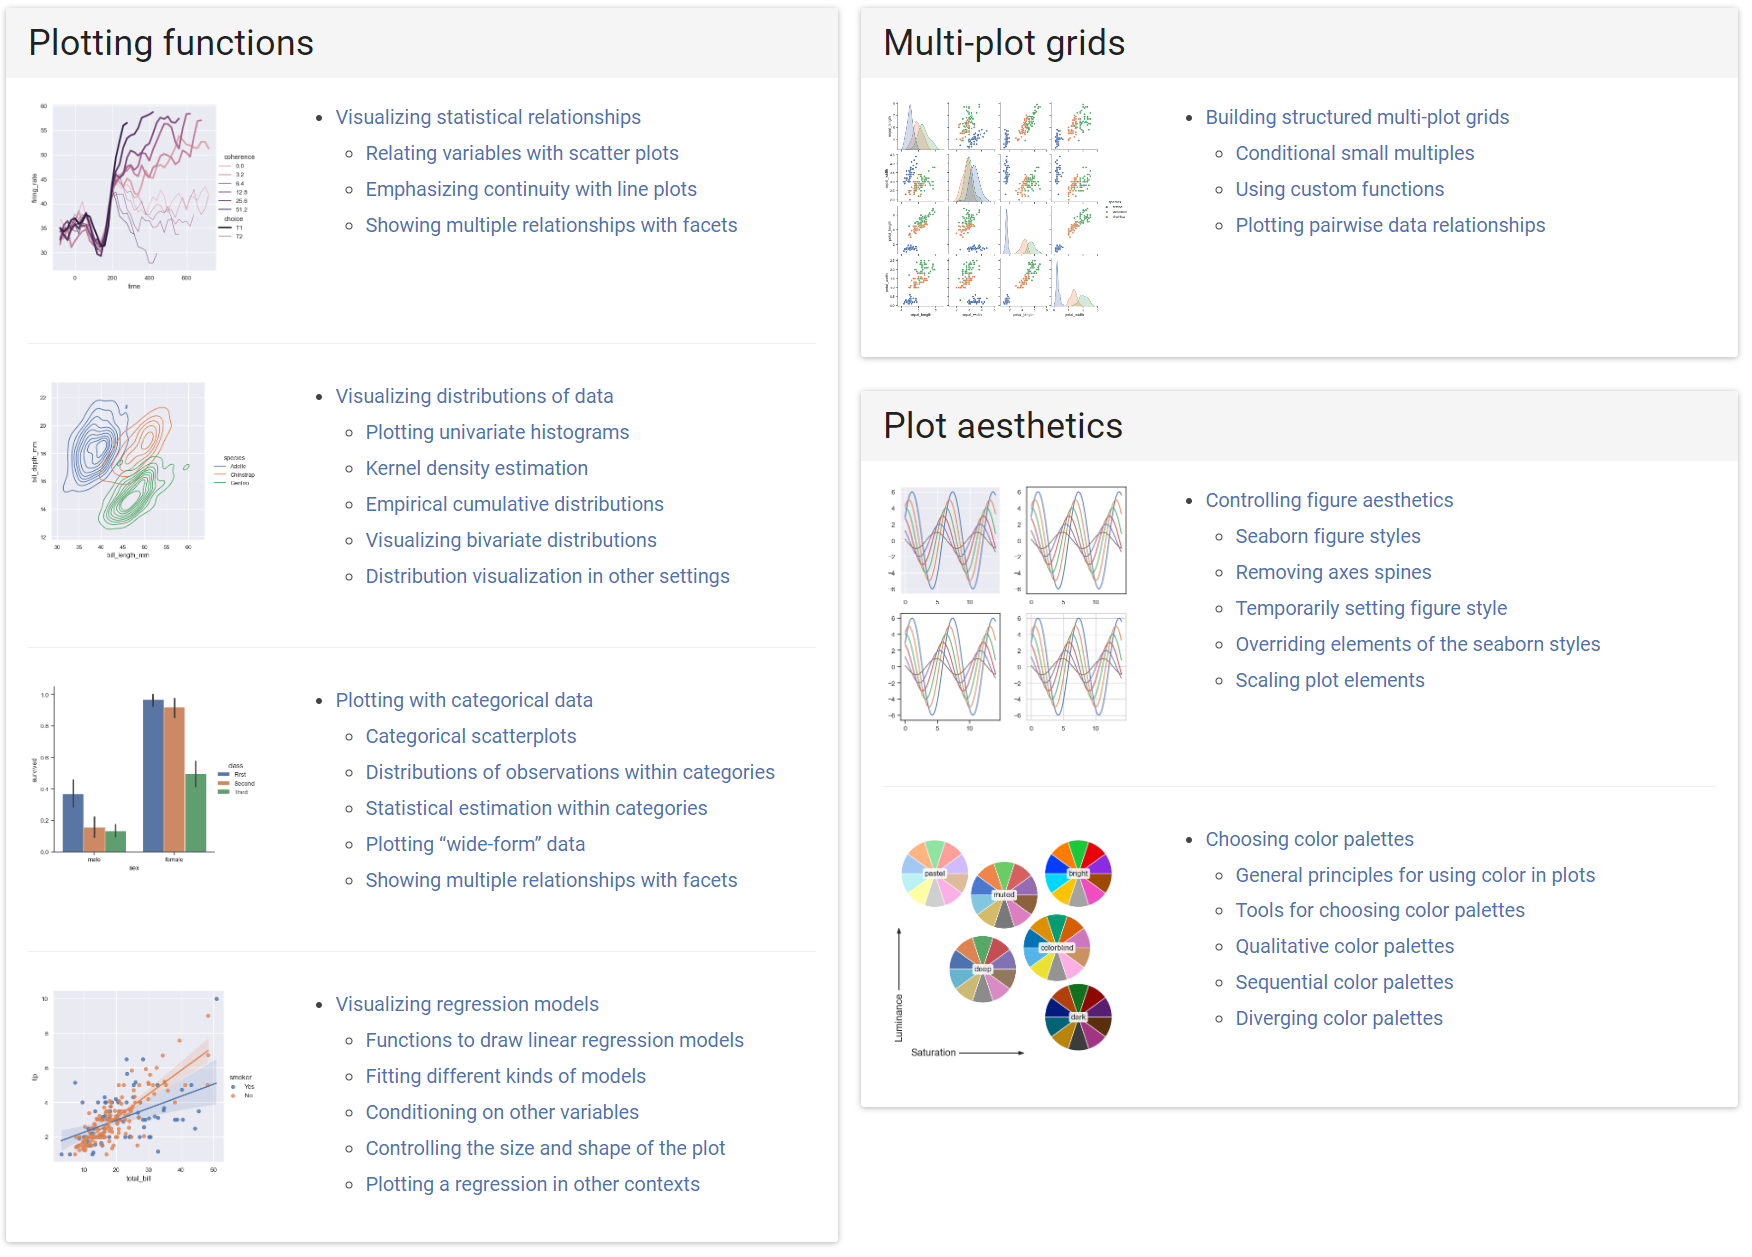

- https://seaborn.pydata.org/examples/index.html
- https://seaborn.pydata.org/tutorial.html

## 패키지 임포트

In [1]:
import numpy as np
import pandas as pd
import matplotlib as mp
import matplotlib.pyplot as plt
import seaborn as sns

print(f'numpy : {np.__version__}, pandas : {pd.__version__}, Matplotlib:{mp.__version__}, seaborn:{sns.__version__}')

numpy : 2.5.2, pandas : 3.0.5, Matplotlib:3.11.1, seaborn:0.13.2


In [2]:
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['font.family'] = 'Malgun Gothic' 

## 지원되는 플롯 유형

- Relational plots
- Distribution plots
- Categorical plots
- Regression plots
- Multi-plot grids
- Figure theming
- Color palettes

![image.png](https://seaborn.pydata.org/_images/function_overview_8_0.png)

------------------------

# 시각화의 목적에 따른 플롯

- 데이터 분포 파악
- 데이터 관계 파악
- 집단간 비교
- 시간에 따른 변화

---

# 1. 데이터 분포(distribution) 파악

- 데이터의 중심(대표), 산포(퍼짐), 왜도, 첨도 등의 분포 특징을 파악하기 위해 사용
- **히스토그램(histogram)**
    - matplotlib.pyplot.hist()
    - seaborn.displot(kind='hist')
    - seaborn.histplot()
    - DataFrame.plot(kind='hist')
    - DataFrame.plot.hist()
- **박스플롯(boxplot)**
    - matplotlib.pyplot.boxplot()
    - seaborn.catplot(kind='box')
    - seaborn.boxplot()
    - DataFrame.plot(kind='box')
    - DataFrame.plot.box()
    - DataFrame.boxplot()    
- **커널 밀도 곡선(Kernel Density Estimation plot)**
    - seaborn.displot(kind='kde')
    - seaborn.kdeplot()
    - DataFrame.plot(kind='kde')
    - DataFrame.plot.kde()

#### 예제 데이터. iris dataset

In [3]:
iris = sns.load_dataset('iris')
iris.head(2)
iris.info()

<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    str    
dtypes: float64(4), str(1)
memory usage: 6.0 KB


## 1) 히스토그램(histogram)

- 표로 되어 있는 도수 분포를 그림으로 나타낸 것
- 계급구간, 계급값, 빈도, 상대빈도

### ① matplotlib.pyplot.hist()
- 형식
    ```python
    hist(x, bins=None, range=None, density=False, cumultive=False, ...)
    ```

<Axes: >

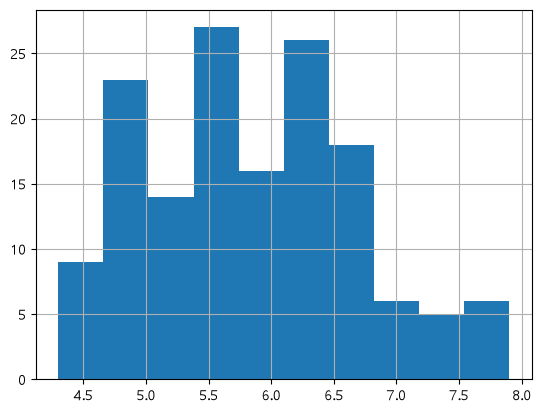

In [4]:
iris.sepal_length.hist()

### ② pandas.DataFrame.hist()

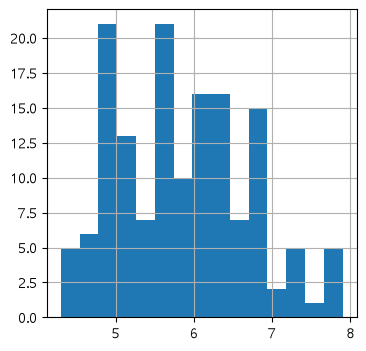

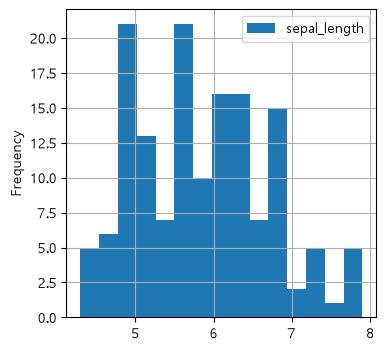

In [5]:
iris.sepal_length.hist(bins=15, grid = True, figsize=(4,4))
iris[['sepal_length']].plot(kind='hist', bins=15, grid = True, figsize=(4,4))
plt.show()

### ③ seaborn의 히스토그램 함수

- 형식1.
    ```python
    seaborn.histplot(data, x, y, hue, weights, stat, bins, binwidth, kde, ...)
    ```
    - 반환 : ax
    - https://seaborn.pydata.org/generated/seaborn.histplot.html#seaborn.histplot
- 형식2.
    ``` python
    displot(kind='hist', x, y, data, hue,...)
    ```
    - https://seaborn.pydata.org/generated/seaborn.displot.html#seaborn.displot

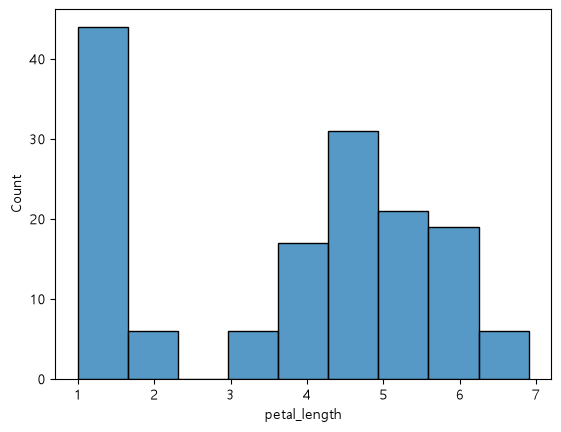

In [6]:
sns.histplot(data=iris,x='petal_length')
plt.show()

#### sns.histplot(**stat**=)
- stat='count' : 각 빈의 관측값수
- stat='frequency' : 각 빈의 너비로 나눈 관측값수
- stat='probability' or 'proportion' : 막대 높이의 합이 1이 되도록 정규화
- stat='percent' : 막대 높이 합이 100이 되도록 정규화
- stat='density' : 히스토그램의 전체 면적이 1이 되도록 정규화

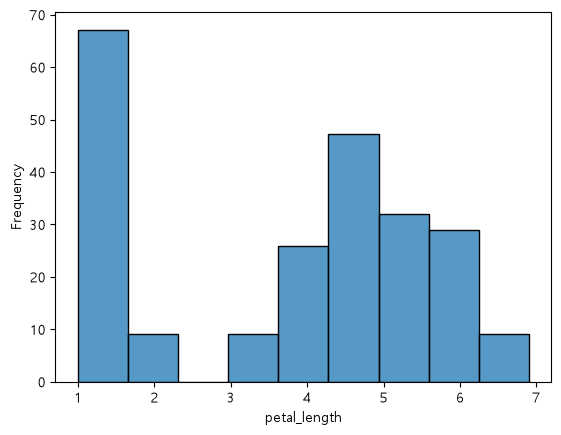

In [7]:
sns.histplot(data=iris, x='petal_length', stat='frequency')
plt.show()

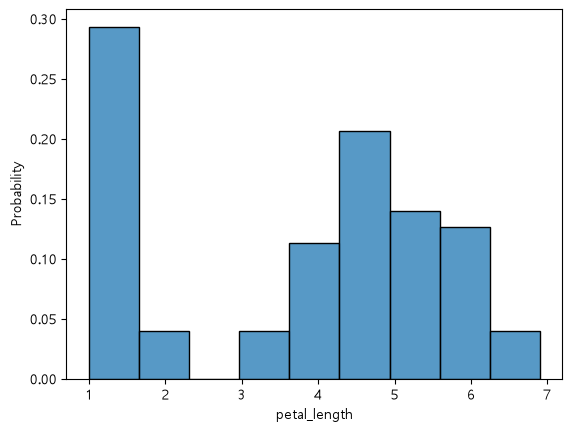

In [8]:
sns.histplot(data=iris, x='petal_length', stat='probability')

plt.show()

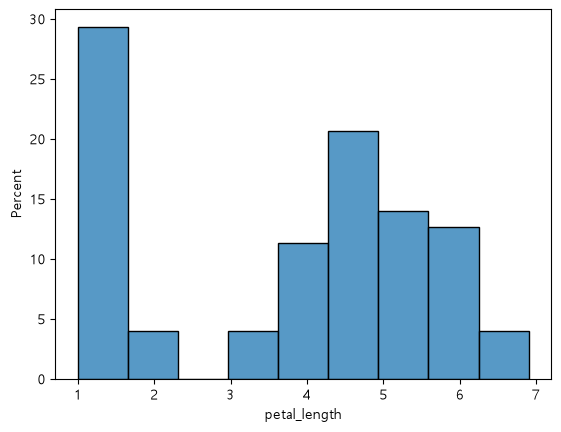

In [9]:
sns.histplot(data=iris, x='petal_length', stat='percent')

plt.show()

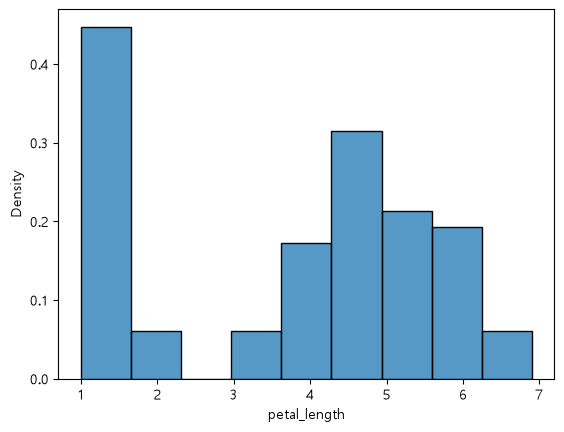

In [10]:
sns.histplot(data=iris, x='petal_length', stat='density')

plt.show()

#### sns.histplot(**kde=True**)
- 커널밀도곡선(Kernel Density Estimation curve)을 히스토그램 위에 그림

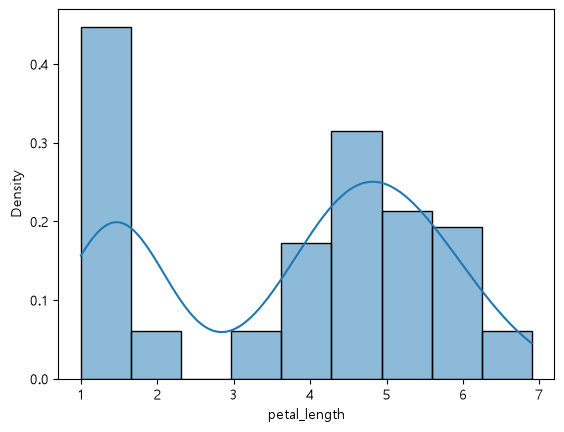

In [11]:
sns.histplot(data=iris, x='petal_length', stat='density', kde=True)

plt.show()

#### sns.histplot(**cumulative**=)

In [12]:
import scipy

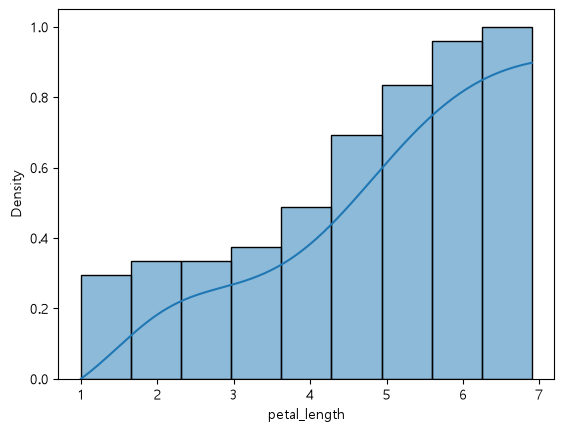

In [13]:
sns.histplot(data=iris, x='petal_length', stat='density', cumulative=True, kde=True)

plt.show()

#### sns.histplot() **data 인수만 지정**할 경우
- 수치형 데이터들에 대한 히스토그램을 모두 그림

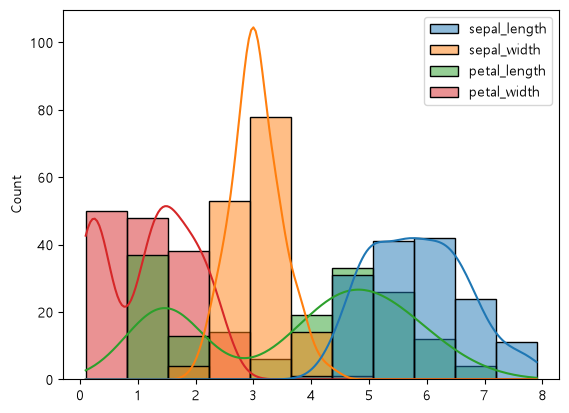

In [14]:
sns.histplot(data=iris, kde = True)

plt.show()

#### sns.histplot()의 **hue 인수**에 범주형 데이터 지정할 경우
- 범주형 변수의 그룹별로 히스토그램을 그려 분포 비교 가능

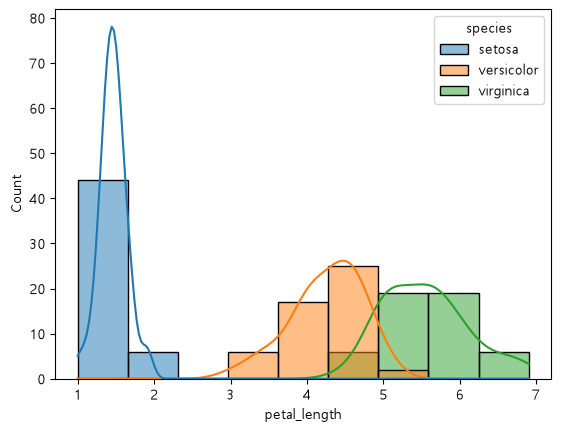

In [15]:
# hue : 범주형 데이터를 지정
sns.histplot(data=iris, x='petal_length', kde=True, hue='species')

plt.show()

#### sns.histplot(**element**=)
- element = 'step' : 계단모양으로 그림
- element = 'poly' : 다각형으로 그림

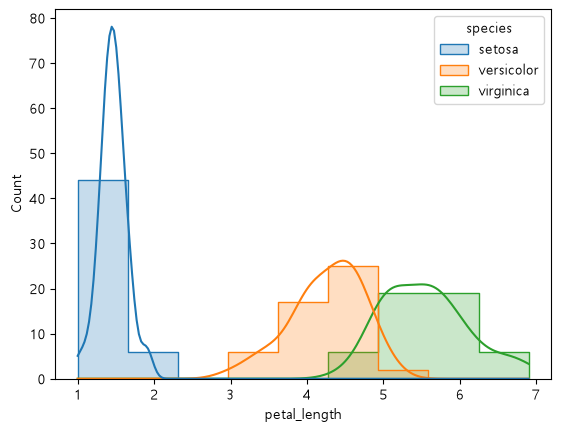

In [16]:
# hue : 범주형 데이터를 지정
sns.histplot(data=iris, x='petal_length', kde=True, hue='species', element='step')

plt.show()

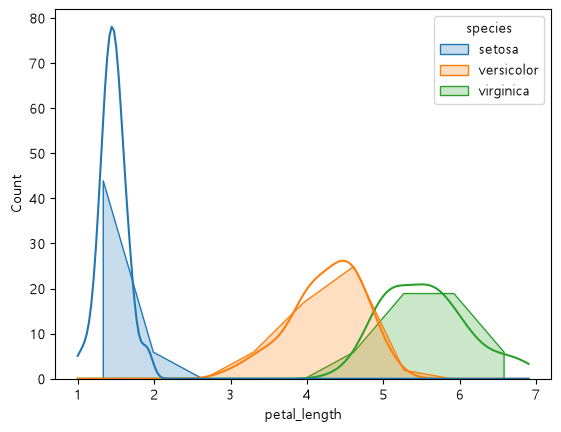

In [17]:
sns.histplot(data=iris, x='petal_length', kde=True, hue='species', element='poly')

plt.show()

#### sns.histplot(**multiple**=)
두 변수가 지정된 경우만 사용
- multiple='layer', 기본값
- multiple='dodge'
- multiple='stack'
- multiple='fill'

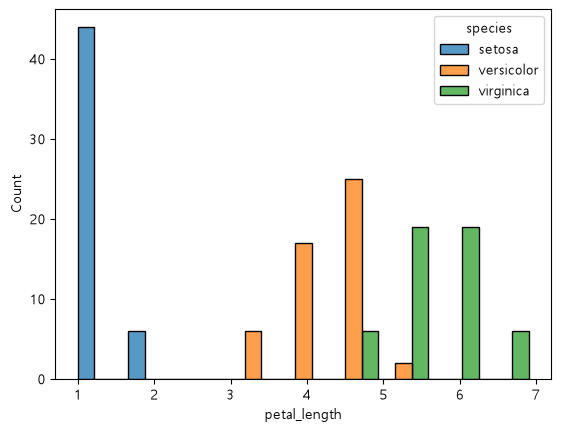

In [18]:
sns.histplot(data=iris, x='petal_length', hue='species', multiple='dodge')

plt.show()

<Axes: xlabel='petal_length', ylabel='Count'>

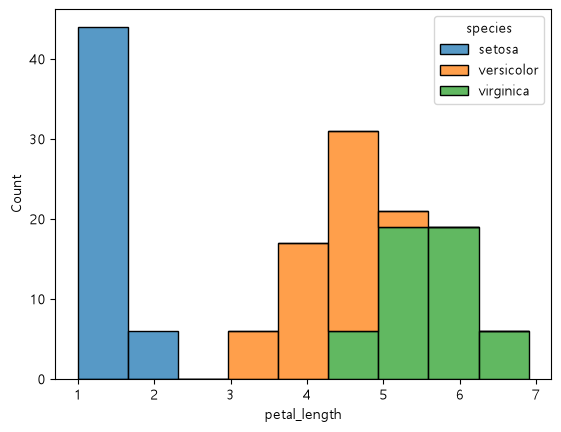

In [19]:
sns.histplot(data=iris, x='petal_length', hue='species', multiple='stack')

<Axes: xlabel='petal_length', ylabel='Count'>

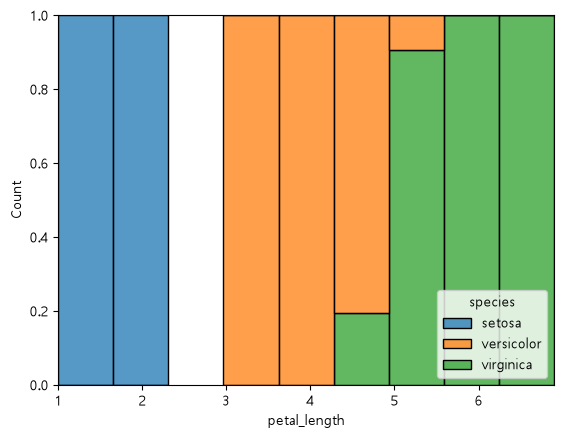

In [20]:
sns.histplot(data=iris, x='petal_length', hue='species', multiple='fill')

### sns.**displot**(**kind='hist'**,) 

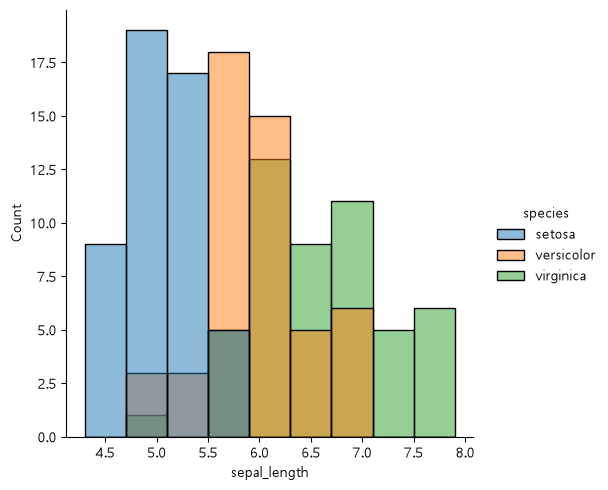

In [21]:
sns.displot(kind='hist', data=iris, x='sepal_length', hue='species', multiple='layer')

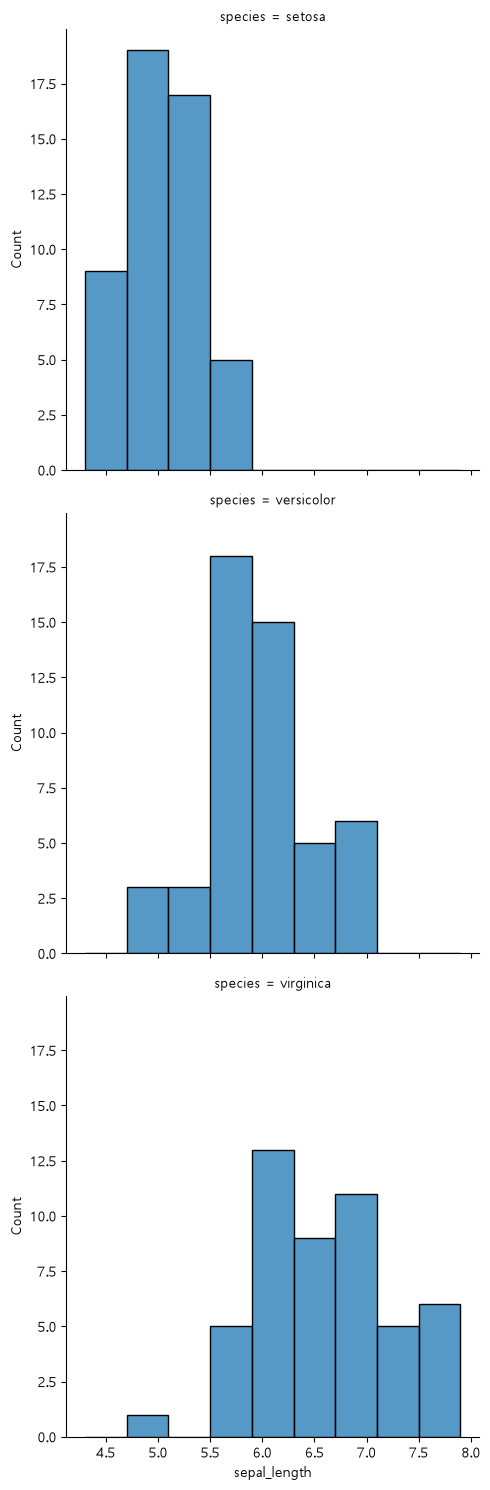

In [22]:
sns.displot(kind='hist', data=iris, x='sepal_length', row='species')
plt.show()

In [23]:
# sns.displot(kind='hist', data=iris, x='sepal_length', row='
# plt.show()

## 2) 박스플롯(boxplot)
- '상자 수염 그림'(box-and-whisker plot) 또는 '상자 그림'(box plot, boxplot)이라 부름
- 수치적 자료를 표현하는 그래프
- 자료로부터 얻어낸 통계량인 5가지 요약 수치(five-number summary)를 가지고 그린다
    - 최소값
    - 제1사분위(Q1, lower quartile)
    - 제2사분위(Q2, median)
    - 제3사분위(Q3, upper quartile)
    - 최대값    
- 이상치 확인
- 분포의 비대칭 확인

### ① matplotlib.pyplot의 박스플롯 함수

- 형식
    ```python
    boxplot(x, notch, sym, vert, whis, widths, ...)
    ```

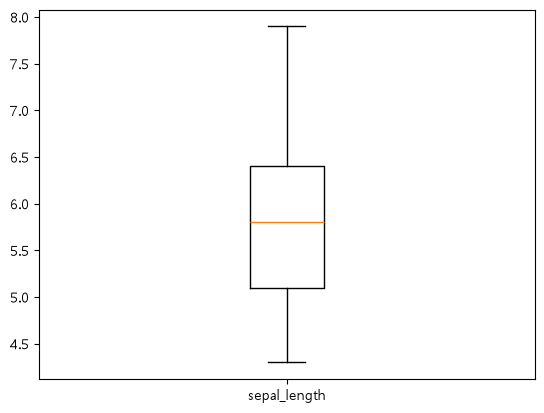

In [24]:
plt.boxplot(iris.sepal_length, tick_labels=['sepal_length'])
plt.show()

In [25]:
# iris.iloc[]

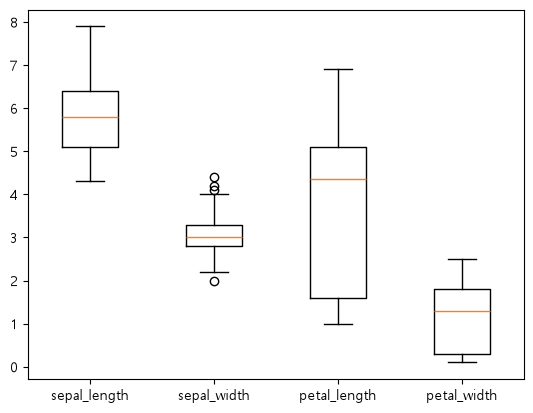

In [26]:
plt.boxplot(iris.iloc[:, :-1], tick_labels=iris.columns[:-1])
plt.show()

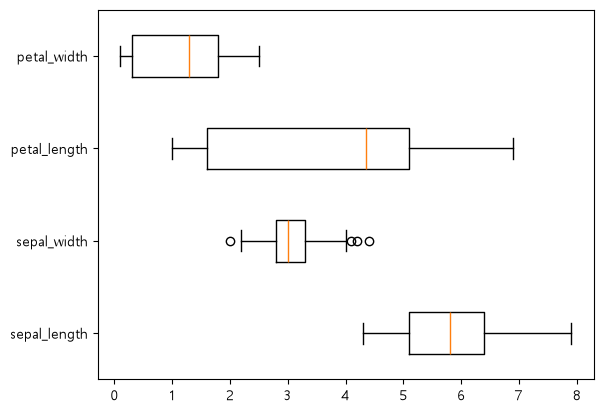

In [27]:
plt.boxplot(iris.iloc[:, :-1], tick_labels=iris.columns[:-1], orientation = 'horizontal')
plt.show()

<Axes: >

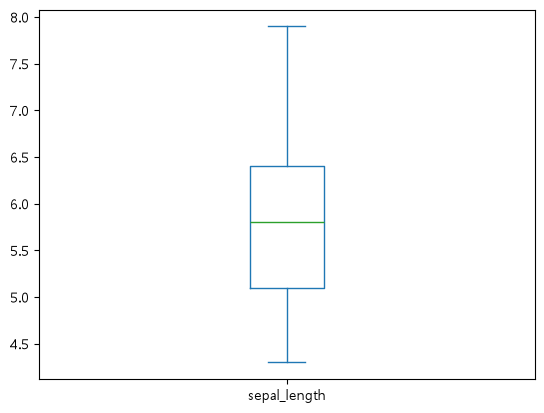

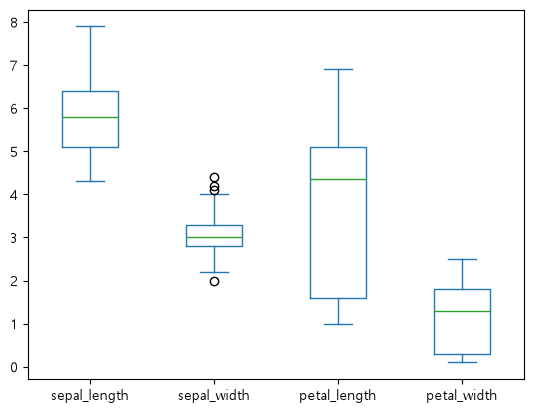

In [28]:
iris['sepal_length'].plot(kind='box')
iris.iloc[:,:-1].plot(kind='box')

<Axes: >

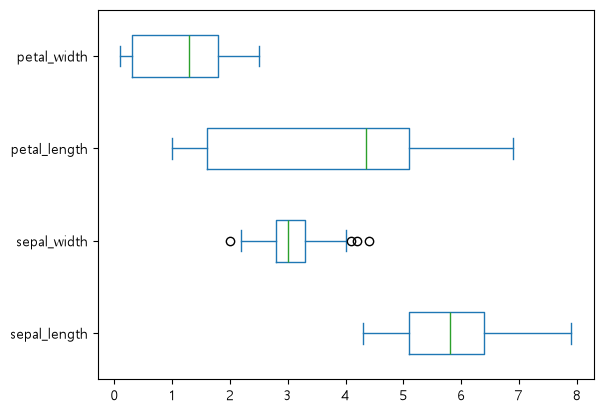

In [29]:
iris.iloc[:,:-1].plot(kind='box', vert=False)

### ② seaborn의 박스플롯 함수
- 형식1.
    ```python
    boxplot(x=None, y=None, hue=None, data=None, order=None, hue_order=None, 
            orient=None, color=None, palette=None, saturation=0.75, width=0.8, 
            dodge=True, fliersize=5, linewidth=None, whis=1.5, ... )
    ```
    - 반환값 : ax (matplotlib Axes)  
- 형식2.
    ```python
    catplot(kind='box', x=None, y=None, hue=None, data=None, ... )
    ```

TypeError: Axes.bxp() got an unexpected keyword argument 'tick_labels'

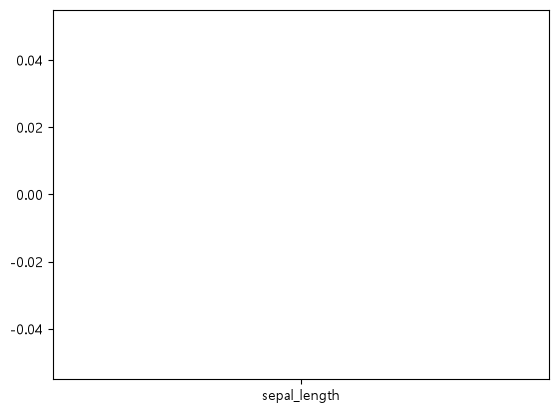

In [30]:
sns.boxplot(iris.iloc[:, :-1], tick_labels=iris.columns[:-1])

#### sns.boxplot(**data=, x=, y=**)
- x : 범주(수치)형 변수
- y : 수치(범주)형 변수
- data : x,y에 지정한 변수를 가진 데이터프레임

In [ ]:
sns.boxplot(data=iris, y='sepal_width')

In [ ]:
sns.boxplot(data=iris, x='sepal_width', y='species')
plt.show()

#### sns.boxplot(**order=**) : 박스플롯 순서 변경

In [ ]:
sns.boxplot(data=iris, x='sepal_width', y='species', order=['versicolor','virginica','setosa'])
plt.show()

#### sns.boxplot(**orient=**) : 박스플롯 방향 변경
- orient = 'h' | 'v'

In [ ]:
sns.boxplot(data=iris, x='sepal_width', y='species', orient='h')
plt.show()

In [ ]:
sns.catplot(kind='box', data=iris)

## 3) 이변량 분포(bivariate distribution)
- 이변량 자료 : 두 변수로 이루어진 분포

### seaborn의 histplot()

In [ ]:
sns.histplot(data=iris, x='sepal_length', y='petal_length')
plt.show()

### seaborn의 displot()

- 형식 : displot(x, y, data, ...)
- https://seaborn.pydata.org/generated/seaborn.displot.html#seaborn.displot

In [ ]:
#sns.displot(data=iris, x='sepal_length', y='petal_length')
sns.displot(data=iris, x='sepal_length', y='petal_length', hue='species')
plt.show()

In [ ]:
sns.displot(data=iris, x='sepal_length', y='petal_length')
sns.displot(data=iris, x='sepal_length', y='petal_length', hue='species', palette='pastel')
sns.displot(kind='kde', data=iris, x='sepal_length', y='petal_length', hue='species',
            palette=['red','green','blue'])
plt.show()

In [ ]:
sns.displot(kind='kde', data=iris, x='sepal_length', y='petal_length', col='species')
plt.show()

#### 참고. seaborn.ecdfplot()

In [ ]:
# sns.displot(kind='ecdf', data=iris, x='sepal_length')
sns.ecdfplot(data=iris, x='sepal_length')

plt.show()

----

# 2. 데이터의 관계 파악

- 변수간 상관성(선형성) 파악
- 변수들간의 관계성 파악
- **산점도(scatter plot)**
    - matplotlib.pyplot.scatter()
    - matplotlib.pyplot.plot()
    - seaborn.relplot(kind='scatter')
    - seaborn.scatterplot()    
    - seaborn.regplot()
    - DataFrame.plot(kind='scatter')
    - DataFrame.plot.scatter()
- **버블플롯(bubble plot)**
    - matplotlib.pyplot.scatter(, s= , c=)
    - seaborn.relplot(kind='scatter', size= ,)
    - seaborn.scatterplot(, size= ,)   
- **산점도행렬(scatterplot matrix)**
    - seaborn.pairplot()
    - pandas.plotting.scatter_matrix()
- 참고. 범주형 변수들에 대한 교차표(분할표) 시각화 -> 모자익(Mosaic plot)
    - https://ko.wikipedia.org/wiki/%EB%AA%A8%EC%9E%90%EC%9D%B4%ED%81%AC_%ED%94%8C%EB%A1%AF
      - 타이타닉 성별/class 별 생존/사망 그래프

## 1) 산점도(scatter plot)

- 두 변수간의 선형성 파악
- 두 변수는 수치형 데이터

In [ ]:
iris = sns.load_dataset('iris')
iris.head(2)

### ① matplotlib.pyplot의 산점도 함수

- 형식.
    ```python
    scatter(x, y, s=None, c=None, marker=None, cmap=None, norm=None, 
            vmin=None, vmax=None, alpha=None, linewidths=None, *, 
            edgecolors=None, plotnonfinite=False, data=None,...)
    ```

In [ ]:
plt.scatter(data=iris, x='sepal_length', y='petal_length')
plt.show()

### ② pandas의 plot.scatter() 이용한 산점도 그리기

In [ ]:
iris.plot(kind='scatter', x='petal_length', y='petal_width',
         s=20, c='green', alpha=0.5)
iris.plot.scatter(x='petal_length', y='sepal_width',
         s=15, c='blue', alpha=0.5)
plt.show()

### ③ seaborn의 산점도 함수

- 형식1.
    ```python
    scatterplot(x=None, y=None, hue=None, style=None, size=None, data=None, palette=None, 
                hue_order=None, hue_norm=None, sizes=None, size_order=None, 
                size_norm=None, markers=True, ... )
    ```
    - https://seaborn.pydata.org/generated/seaborn.scatterplot.html#seaborn.scatterplot  
- 형식2.
    ```python
    relplot(kind='scatter', x=None, y=None, hue=None, size=None, data=None, ... )
    ```
    - https://seaborn.pydata.org/generated/seaborn.relplot.html#seaborn.relplot    
- 형식3.
    ```python
    regplot(x=None, y=None, data=None, x_estimator=None, x_bins=None, 
            x_ci='ci', scatter=True, fit_reg=True, ci=95,...)
    ```
    - https://seaborn.pydata.org/generated/seaborn.regplot.html#seaborn.regplot

### **sns.scatterplot()**

In [ ]:
sns.scatterplot(data=iris, x='petal_width', y='sepal_width')
plt.show()

#### sns.scatterplot(**hue**=)
- 범주형 변수의 범주에 따라 다른 색상으로 표시

In [ ]:
sns.scatterplot(data=iris, x='petal_width', y='sepal_width',hue='species')
plt.show()

#### sns.scatterplot(**style**=)
- 범주형 변수의 범주에 따라 마커 모양을 다르게 표현

In [ ]:
sns.scatterplot(data=iris, x='petal_width', y='sepal_width', 
                style='species')
plt.show()
sns.scatterplot(data=iris, x='petal_width', y='sepal_width', 
                hue='species', style='species')
plt.show()
sns.scatterplot(data=iris, x='petal_width', y='sepal_width', 
                hue='species', style='species', alpha = 0.5)
plt.show()

#### sns.scatterplot(**s**=)
- 마커 크기 변경

In [ ]:
sns.scatterplot(data=iris, x='petal_width', y='sepal_width', 
                hue='species', style='species', alpha = 0.5, s=100)
plt.show()

#### scatterplot(**alpha**=)
- 스타일 변경

In [ ]:
sns.scatterplot(data=iris, x='petal_width', y='sepal_width', 
                hue='species', style='species', alpha = 0.5)
plt.show()

#### scatterplot(**size**=)

In [ ]:
sns.scatterplot(data=iris, x='petal_width', y='petal_length', 
                hue='species', size=1)
plt.show()
sns.scatterplot(data=iris, x='petal_width', y='petal_length', 
                hue='species', size='sepal_width')
plt.show()

### **sns.relplot(kind='scatter')**

In [ ]:
sns.relplot(data=iris, x='petal_width', y='petal_length', hue='species')
plt.show() # 변수 2개면 기본적으로 scatter로 해줌
sns.relplot(kind='scatter', data=iris, x='petal_width', y='petal_length', hue='species')
plt.show()

#### sns.relplot(**palette**=)
- seaborn에서 제공되는 팔레트
- https://seaborn.pydata.org/tutorial/color_palettes.html

In [ ]:
sns.color_palette()

In [ ]:
# 컬러 맵 설정
sns.color_palette('dark')

In [ ]:
sns.relplot(kind='scatter', data=iris,
            x='petal_width', y='petal_length', hue='species', alpha = 0.5)
plt.show()
sns.relplot(kind='scatter', data=iris,
            x='petal_width', y='petal_length', hue='species', palette='dark', alpha=0.5)
plt.show()

#### sns.relplot(**col**=)

In [ ]:
sns.relplot(kind='scatter', data=iris,
            x='petal_width', y='petal_length', col='species',
            alpha=0.5, s=50)
plt.show()

### **sns.regplot()** 을 이용한 산점도

#### sns.regplot(**fit_reg=False**)
- 선형회귀 적합 선을 포함시키지 않을 때

In [ ]:
sns.regplot(data=iris, x='petal_width', y='petal_length')
plt.show()
sns.regplot(data=iris, x='petal_width', y='petal_length', fit_reg=False)
plt.show()

#### sns.regplot(**fit_reg=True**)

In [ ]:
sns.regplot(data=iris, x='petal_width', y='petal_length', fit_reg=True)
plt.show()

## 2) 산점도 행렬(scatter plot matrix)

: 여러 개의 연속형 변수에 대해서 두 변수씩 쌍을 이루는 산점도를 그려 한꺼번에 변수 간 관계를 일목요연하게 볼 수 있음

###  ① seaborn.pairplot()을 이용한 산점도 행렬

- 형식
    ```python
    pairplot(data, hue=None, hue_order=None, palette=None, vars=None, x_vars=None, 
             y_vars=None, kind='scatter', diag_kind='auto', markers=None, 
             height=2.5, aspect=1, corner=False, dropna=False, plot_kws=None, 
             diag_kws=None, grid_kws=None, size=None)
    ```
- https://seaborn.pydata.org/generated/seaborn.pairplot.html#seaborn.pairplot

#### sns.pairplot()의 인수
- kind='scatter' : 각 행렬 위치에 scatter|kde|hist 등을 표시
- diag_kind='kde' : 각 변수별 커널밀도추정곡선 그림
- hue='species' : 'species'(setosa, versicolor, virginica) 별로 색깔을 다르게 표시
- 색깔은 palette 에 'bright', 'pastel', 'deep', 'muted', 'colorblind', 'dark' 중에서 가독성이 좋고 선호하는 색상으로 선택
- corner :  상감각의 산점도는 표시하지 않음

In [ ]:
sns.pairplot(data=iris)

In [ ]:
# sns.pairplot(data=iris, diag_kind='hist') -> 대각행렬 hist가 기본값
sns.pairplot(data=iris, diag_kind='kde')
plt.show()
sns.pairplot(data=iris, diag_kind='kde', corner=True)
plt.show()

In [ ]:
sns.pairplot(data=iris, diag_kind='kde', corner=True, kind='reg')
plt.show()

In [ ]:
sns.pairplot(data=iris, kind='hist', diag_kind='kde', corner=True)
plt.show()

In [ ]:
sns.pairplot(data=iris, kind='kde', diag_kind='kde', corner=True)
plt.show()

### ② pandas.plotting 의 scatter_matrix() 함수를 사용하여 산점도 행렬

- 형식
    ```python
    scatter_matrix(frame, alpha=0.5, figsize=None, ax=None, grid=False, 
                   diagonal='hist', marker='.', density_kwds=None, 
                   hist_kwds=None, range_padding=0.05, **kwargs)
    ```
- https://pandas.pydata.org/docs/reference/api/pandas.plotting.scatter_matrix.html

In [ ]:
from pandas.plotting import scatter_matrix

scatter_matrix(iris, diagonal='kde', figsize=(8,8))
plt.show()

In [ ]:
sns.pairplot(data=iris, diag_kind='kde', hue='species', corner=True)
plt.show()

## 3) 버블 플롯

: 산점도에서 x, y이외의 다른 변수를 포인트의 크기로 매핑하여 변수들간의 관계를 파악하게 함

In [ ]:
iris.iloc[49:51, :]

In [ ]:
iris.iloc[99:101, :]

### ① matplotlib.pyplot의 scatter()를 이용한 버블플롯 

- scatter()의 s, c 인수 사용

In [ ]:
sizes = iris.petal_length*10
colors = ['r']*50 + ['g']*50 + ['b']*50

In [ ]:
plt.scatter(data=iris, x='sepal_length', y='sepal_width', s=sizes, c=colors)
plt.show()
plt.scatter(data=iris, x='sepal_length', y='sepal_width', s=sizes, c=colors, marker='^')
plt.show()

In [ ]:
colors = ['r','g','b']
markers = ['d','o','^']
values = ['setosa', 'versicolor', 'virginica']

for i, value in enumerate(values):
    df = iris[iris.species == value]
    x = df.sepal_length
    y = df.sepal_width
    s = df.petal_length *10
    plt.scatter(x=x, y=y, c=colors[i], marker=markers[i], label=value, s=s)

plt.legend()
plt.show()

In [ ]:
sns.relplot(kind='scatter', data=iris, x='petal_width', y='petal_length',
            hue='species', size='sepal_length')
plt.show()

### ② seaborn의 산점도 함수를 이용한 버블 플롯

- sns.scatterplot() 또는 relplot()의 size인수 사용

In [ ]:
sns.relplot(kind='scatter', data=iris, x='petal_width', y='petal_length',
            hue='species', size='sepal_length', sizes=(20,200) )
plt.show()
sns.relplot(kind='scatter', data=iris, x='petal_width', y='petal_length',
            size='sepal_length', sizes=(20,200) )
plt.show()

## 3. 집단 간 비교

: 그룹별 데이터 분포 비교
- FacetGrid를 이용한 범주형 플롯 시각화
- **막대그래프(barplot)**
    - matplotlib.pyplot.bar()
    - matplotlib.pyplot.barh()
    - DataFrame.plot(kind='bar'|'barh')
    - DataFrame.plot.bar()
    - DataFrame.plot.barh()
    - seaborn.barplot()
    - seaborn.catplot(kind='bar')
- **바이올린플롯(violin plot)**
    - matplotlib.pyplot.violinplot()
    - seaborn.viloinplot()
    - seaborn.catplot(kind='violin')
- **strip plot**
    - seaborn.stripplot()
    - seaborn.catplot(kind='strip')
- **swarm plot**
    - seaborn.swarmplot()
    - seaborn.catplot(kind='swarm')

In [ ]:
titanic= sns.load_dataset('titanic')
titanic.tail()

### 1) 막대 그래프(barplot)

: 범주형 데이터의 범주별 빈도 비교

### ① matplotlib.pyplot의 막대그래프 함수

- 형식
    ```python
    bar(x, height, width=0.8, bottom=None, align='center', data=None,...)
    barh(y, width, height=0.8, left=None, *, align='center', **kwargs)
    ```

In [ ]:
surv_cnt = titanic.survived.value_counts()
surv_cnt

In [ ]:
surv_cnt.index = ['사망', '생존']
surv_cnt

In [ ]:
plt.figure(figsize=(4,4))
plt.bar(x=surv_cnt.index, height=surv_cnt.values)
plt.show()

In [ ]:
plt.figure(figsize=(3,3))
plt.bar(x=surv_cnt.index, height=surv_cnt.values)
plt.show()
plt.figure(figsize=(3,3))
plt.bar(x=surv_cnt.index, height=surv_cnt.values, width=0.7) # 0.8이 기본
plt.show()

In [ ]:
plt.figure(figsize=(4,4))
plt.barh(y=surv_cnt.index, width=surv_cnt.values)
plt.show()
plt.figure(figsize=(4,4))
plt.barh(y=surv_cnt.index, width=surv_cnt.values, height=0.6) # 기본값 0.8
plt.show()

### ② seaborn의 막대그래프 함수

- 형식
    ```python
    barplot(x=None, y=None, hue=None, data=None, order=None, orient='v'|'h', dodge=True, ...)
    countplot(data=None, *, x=None, y=None, hue=None, order=None, hue_order=None,...)
    catplot(kind='bar | count', x=None, y=None, hue=None, data=None, row=None, col=None,...)
    ```
- https://seaborn.pydata.org/generated/seaborn.barplot.html#seaborn.barplot 
- https://seaborn.pydata.org/generated/seaborn.countplot.html
- https://seaborn.pydata.org/generated/seaborn.catplot.html#seaborn.catplot

### **sns.countplot()**
: 빈도 플롯

In [ ]:
ax = sns.countplot(data=titanic, x='alive')
ax.bar_label(ax.containers[0])
plt.show()

In [ ]:
sns.countplot(data=titanic, x='class')
plt.show()
sns.countplot(data=titanic, y='class')
plt.show()

In [ ]:
sns.countplot(data=titanic, x='class', width=0.9)
plt.show()
sns.countplot(data=titanic, y='class', width=0.9)
plt.show()

In [ ]:
sns.countplot(data=titanic, x='class', width=0.7, hue='alive')
plt.show()
sns.countplot(data=titanic, x='class', width=0.7, hue='alive', dodge=False)
plt.show() # dodge 기본 True

In [ ]:
sns.countplot(
    data=titanic,
    x='class',
    hue='alive',
    hue_order=['yes', 'no'],  # 원하는 순서 지정
    dodge=False
)
plt.show()

In [ ]:
# 1. 피벗 테이블로 데이터 집계
df_pivot = titanic.pivot_table(
    index='class', columns='alive', aggfunc='size', fill_value=0
)

# 2. 작은 값이 아래로 오도록 컬럼 순서 정렬 (예: 합계가 작은 순)
df_pivot = df_pivot[df_pivot.sum().sort_values().index]

# 3. 누적 막대 그래프 그리기
ax = df_pivot.plot(kind='bar', stacked=True, figsize=(6, 5))
plt.show()

### **sns.barplot()**

In [ ]:
ax = sns.barplot(data=titanic, y='survived')
ax.bar_label(ax.containers[0])
plt.show()

In [ ]:
titanic['survived'].value_counts() / titanic['survived'].shape[0]

In [ ]:
df = pd.crosstab(index=titanic.sex, columns=titanic.survived,
            margins=True)

print(df)
df[1]/df['All']

In [ ]:
ax = sns.barplot(data=titanic, y='survived', hue='pclass')
for c in ax.containers:
    ax.bar_label(c)
plt.show()

In [ ]:
pd.crosstab(index=titanic.pclass, columns=titanic.survived,
            normalize=True, margins=True)

In [ ]:
pd.crosstab(index=titanic.sex, columns=titanic.survived,
            normalize=True, margins=True)

In [ ]:
ax = sns.barplot(data=titanic, x='sex', y='survived')
ax.bar_label(ax.containers[0])
plt.show()

In [ ]:
# 성별과 선실등급에 따른 생존율
sns.barplot(data=titanic, x='sex', y='survived', hue='class')
plt.show()

In [ ]:
sns.barplot(data=titanic, x='class', y='survived', hue='sex')
plt.show()

#### sns.barplot(dodge=False)
: 겹쳐서 그림

In [ ]:
sns.barplot(data=titanic, x='sex', y='survived', hue='class', dodge=False)
plt.show()

### **sns.catplot(kind='bar')**

In [ ]:
sns.catplot(kind='bar', data=titanic, x='sex', y='survived', hue='class')
plt.show()

#### sns.catplot(**col**=)
: 윈도우에 범주별 막대그래프를 따로 표현

In [ ]:
sns.catplot(kind='bar', data=titanic, x='sex', y='survived', col='class')
plt.show()

### 참고. countplot()과 batplot() 비교

In [ ]:
data = pd.DataFrame({'cate':['A','B','A','A','B','A','B','A'],
                     'value' :[10, 13, 12, 8, 9, 5, 10, 20]})
data.info()

In [ ]:
data.groupby('cate').mean()

In [ ]:
ax = sns.barplot(data=data, x='cate')
ax.bar_label(ax.containers[0])
plt.show()
sns.barplot(data=data, x='cate', y='value')
plt.show()

In [ ]:
sns.catplot(kind='bar', data=data, x='cate', y='value')
plt.show()

### 연습1. Tips 데이터에서 요일별 평균결제금액 비교하기

In [ ]:
tips = sns.load_dataset('tips')
tips.head()

In [ ]:
sns.boxplot(data=tips, x='total_bill', y='day')
plt.show()

In [ ]:
pd.pivot_table(data=tips, index='day', values='total_bill', aggfunc='mean')

In [ ]:
sns.barplot(data=tips, x='day', y='total_bill')

### 연습2. Tips 데이터에서 성별 인원수 시각화

In [ ]:
sns.countplot(data=tips, x='sex')
sns.displot(data=tips, x='sex')
plt.show()

## 2) 바이올린 플롯(violin plot)

- 박스플롯의 기능과 함께 데이터의 커널밀도곡선을 제시
- 데이터의 분포와 범위를 한눈에 보기 쉽게 나타내는 그래프
- 더 실제에 가까운 분포를 알 수 있음

#### 예제 데이터. iris dataset

### ① matplotlib.pyplot의 바이올린 플롯 함수

- 형식
    ```python
    violinplot(dataset, positions=None, vert=True, widths=0.5,  *, data=None)
    ```
- https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.violinplot.html

In [ ]:
plt.figure(figsize=(4,4))
plt.violinplot(iris.sepal_length)
plt.show()

In [ ]:
iris.head(1)

In [ ]:
plt.figure(figsize=(4,4))
plt.violinplot(iris.iloc[:,:-1])
plt.xticks([1,2,3,4], labels=iris.columns[:-1])
plt.show()

In [ ]:
plt.figure(figsize=(4,4))
# plt.violinplot(iris.iloc[:,:-1], vert=False)
plt.violinplot(iris.iloc[:,:-1], orientation='horizontal')
plt.yticks([1,2,3,4], labels=iris.columns[:-1])
plt.show()

### ② seaborn의 바이올린 플롯 함수

- 형식
    ```python
    violinplot(x=None, y=None, hue=None, data=None, order=None, ...)
    catplot(kind='violin', x=None, y=None, hue=None, data=None, row=None, col=None,...)
    ```
- https://seaborn.pydata.org/generated/seaborn.violinplot.html#seaborn.violinplot
- https://seaborn.pydata.org/generated/seaborn.catplot.html#seaborn.catplot

### **sns.violinplot()**

In [ ]:
plt.figure(figsize=(4,2))
sns.violinplot(data=iris, x='sepal_length')
plt.show()

In [ ]:
plt.figure(figsize=(6,3))
sns.violinplot(data=iris)
plt.show()

In [ ]:
plt.figure(figsize=(6,3))
sns.violinplot(data=iris, orient = 'h')
plt.show()

In [ ]:
plt.figure(figsize=(4,3))
sns.violinplot(data=iris, x='sepal_length', y='species')
plt.show()

### **sns.catplot(kind='violin')**

In [ ]:
plt.figure(figsize=(3,3))
sns.catplot(kind='violin', data=iris, orient='h')
plt.show()

In [ ]:
plt.figure(figsize=(3,3))
sns.catplot(kind='violin', data=iris, x='petal_length', col='species', orient='h')
plt.show()

## 3) Strip plot

: 겹치는 데이터를 파악할 수 있도록 같은 값에 jitter를 통해 겹치지 않게 그려주는 그래프

- 형식
    ```python
    stripplot(x=None, y=None, hue=None, data=None, order=None, jitter=True, ...)
    catplot(kind='strip', x=None, y=None, hue=None, data=None, row=None, col=None,...)
    ```
- https://seaborn.pydata.org/generated/seaborn.stripplot.html#seaborn.stripplot  
- https://seaborn.pydata.org/generated/seaborn.catplot.html#seaborn.catplot

### **sns.stripplot()**

In [ ]:
iris.sepal_length.unique()
iris.sepal_length.value_counts().sort_index()

In [ ]:
sns.stripplot(data=iris, x='sepal_length')
plt.show()
sns.stripplot(data=iris, x='sepal_length', jitter=False)
plt.show()

In [ ]:
sns.stripplot(data=iris, x='sepal_length', y='species')
plt.show()

In [ ]:
sns.stripplot(data=iris, orient='h')
plt.show()

### **sns.catplot(kind='strip')**

In [ ]:
plt.figure(figsize=(4,2))
sns.catplot(kind='strip', data=iris, x='petal_length', y='species')

In [ ]:
plt.figure(figsize=(2,3))
sns.catplot(kind='strip', data=iris, x='petal_length', col='species')
plt.show()

In [ ]:
plt.figure(figsize=(1,6))
sns.catplot(kind='strip', data=iris, x='petal_length', row='species')
plt.show()

## 4) Swarm plot

- 데이터의 분산까지 고려하여 겹치는 데이터를 겹치지 않게 그려주는 그래프
- 데이터가 퍼져 있는 정도를 입체적으로 볼 수 있음

- 형식
    ```python
    swarmplot(x=None, y=None, hue=None, data=None, order=None, ...)
    catplot(kind='swarm', x=None, y=None, hue=None, data=None, row=None, col=None,...)
    ```
- https://seaborn.pydata.org/generated/seaborn.swarmplot.html#seaborn.swarmplot
- https://seaborn.pydata.org/generated/seaborn.catplot.html#seaborn.catplot

In [ ]:
sns.catplot(kind='swarm', data=iris, x='petal_length')
plt.show()

#### box plot과 swarmplot을 같이 표시

In [ ]:
sns.boxplot(data=iris, x='petal_length', y='species')
sns.swarmplot(data=iris, x='petal_length', y='species', alpha=0.5)
sns.stripplot(data=iris, x='petal_length', y='species', alpha=0.7)
plt.show()

------

## 4. 시간에 따라 변화하는 데이터 표현

- 시계열 데이터 시각화
- 시간에 따른 추세 파악
- 선그래프(line plot)
    - matplotlib.pyplot.plot()
    - seaborn.lineplot()
    - seaborn.relplot(kind='line')
    - DataFrame.plot(kind='line')
    - DataFrame.plot.line()

### 예제 데이터. 미세먼지

In [ ]:
# 엑셀파일 입출력을 위한 openpyxl 설치
import openpyxl

In [ ]:
dust = pd.read_excel('data/fine_dust.xlsx', index_col='area')
dust.tail()

### ① matplotlib의 plot()을 이용하여 라인플롯 그리기

- 형식
    ```python
    plot(x, y, fmt, ..., data=None, scalex=True, scaley=True, **kwargs)
        - x, y : array-like or scalar
        - fmt : str, optional
    ```

In [ ]:
# 서울의 연도별 미세먼지 선그래피 그리기
plt.figure(figsize=(10,3))
#plt.plot( dust.columns, dust.loc['Seoul'], color='b', marker='o')
# plt.plot( dust.loc['Seoul'], color='b', marker='o')
plt.plot( dust.loc['Seoul'], color='b', marker='o', data=dust)
plt.title('2001~2019 미세먼지 농도')

plt.xlabel('연도')
plt.ylabel('미세먼지 농도')
plt.xticks(range(2001,2020))
plt.show()

# sns.lineplot(data=dust.loc['Seoul'])
# plt.xticks(dust.columns, rotation=45)
# plt.show()

# dust.loc['Seoul'].plot(kind='line', figsize=(2,2))
# plt.show()

In [ ]:
dust.columns = dust.columns.astype('str')

In [ ]:
plt.plot( dust.index, '2010', color='b', marker='o', data=dust)

plt.title('2001~2019 미세먼지 농도')

plt.xlabel('연도')
plt.ylabel('미세먼지 농도')
#plt.xticks(range(2001,2020))
plt.xticks(rotation=45)
plt.show()

#### plot(**data**=)
- indexable object : If given, provide the label names to plot in x and y.

In [ ]:
dust.columns = dust.columns.astype(int)
dust.columns

In [ ]:
# 2010년 지역별 미세먼지 농도(비교)
plt.figure(figsize=(15,4))
plt.plot(dust.T.columns, color='b', marker='o', data=dust.T)

plt.title('2010년 지역별 미세먼지 농도')
plt.xlabel('지역')
plt.ylabel('미세먼지')
plt.grid()
plt.show()

In [ ]:
# dust.T.plot(kind='line', figsize=(10, 15))
# plt.show()
dust.index

In [ ]:
data= dust.loc[['Seoul','Gyeonggi','Incheon','Busan']].T

In [ ]:
data.tail(2)

In [ ]:
plt.figure(figsize=(15, 4))
plt.plot(dust.T.index, 'Seoul', color='b', data=dust.T)
plt.title('2001~2019 미세먼지 농도')
plt.xlabel('연도')
plt.ylabel('미세먼지')
plt.xticks(range(2001, 2020))
plt.grid()
plt.show()

In [ ]:
sns.lineplot(data=data)
plt.show()

### ② seaborn의 선그래프 함수 이용

- 형식
    ```python
    lineplot(* , x=None, y=None, hue=None, size=None, style=None,
             data=None, palette=None,...)
    relplot(kind='line', x=None, y=None, hue=None, size=None, 
            style=None, data=None, row=None, col=None,...)
    ```
- https://seaborn.pydata.org/generated/seaborn.lineplot.html#seaborn.lineplot
- https://seaborn.pydata.org/generated/seaborn.relplot.html#seaborn.relplot

### sns.lineplot()

In [ ]:
plt.figure(figsize=(15, 4))
sns.lineplot(data=data)
plt.title('2001~2019 미세먼지 농도: 서울 경기, 인천, 부산')
plt.xlabel('연도')
plt.ylabel('미세먼지')
plt.xticks(range(2001, 2020))
plt.grid()
plt.show()

#### seaborn의 set_style() 이용하여 라인플롯 그리기
- set_style()
    - https://seaborn.pydata.org/generated/seaborn.set_style.html
- axes_style()
    - https://seaborn.pydata.org/generated/seaborn.axes_style.html

In [ ]:
sns.set_style('darkgrid')
plt.figure(figsize=(15,4))
sns.lineplot(data=data)
plt.xlabel('Year')
plt.ylabel('Dust')
plt.xticks(range(2001,2020))
sns.despine(right=True, left=True, top=False, bottom=False)
plt.show()

**sns.despine() 함수를 이용한 그림 테두리 제거**

: sns.despine(right=True,left=True,top=False,bottom=False)

In [ ]:
sns.set_style("whitegrid")
sns.barplot(x=["A", "B", "C"], y=[1, 3, 2])

### ③ pandas.DataFrame.plot(kind='line') 이용

In [ ]:
sns.set_style('white')
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['font.family'] = 'Malgun Gothic' 
dust.T.plot(figsize=(15,4), xlabel='연도', ylabel='미세먼지', title='2001~2019 미세먼지 농도추이')
plt.xticks(range(2001,2020))
plt.grid(True)
plt.show()

------------------------------------------------

# 5. 히트맵(heatmap)

In [ ]:
bike = pd.read_csv('data/bike.csv')
bike.head(2)

## (1) sns.heatmap()

- 범주형-범주형-수치형 자료의 시각화
    - X축과 Y축에 2개의 범주형 자료의 계급(class)별로 연속형 자료를 집계한 자료의 시각화
- 집계한 값에 비례하여 색깔을 다르게 해서 2차원으로 자료를 시각화
- 형식
    ```python
    heatmap(data, vmin=None, vmax=None, cmap=None, center=None, robust=False, annot=None,
            fmt='.2g', annot_kws=None, linewidths=0, linecolor='white', cbar=True, 
            cbar_kws=None, cbar_ax=None, square=False, xticklabels='auto', 
            yticklabels='auto', mask=None, ax=None, **kwargs)
    ```
- https://seaborn.pydata.org/generated/seaborn.heatmap.html#seaborn.heatmap

### 예제 데이터
- 캐글 자전거수요예측 데이터
- https://www.kaggle.com/competitions/bike-sharing-demand

- datetime : hourly date + timestamp (날짜와 시간)
- season : 1 = spring, 2 = summer, 3 = fall, 4 = winter (계절)
- holiday : whether the day is considered a holiday (휴일)
- workingday ; whether the day is neither a weekend nor holiday (평일)
- weather
    - 1: Clear, Few clouds, Partly cloudy, Partly cloudy (맑은 날씨)
    - 2: Mist + Cloudy, Mist + Broken clouds, Mist + Few clouds, Mist (안개)
    - 3: Light Snow, Light Rain + Thunderstorm + Scattered clouds, Light Rain + Scattered clouds (가벼운 눈, 비)
    - 4: Heavy Rain + Ice Pallets + Thunderstorm + Mist, Snow + Fog (폭설, 폭우)
- temp : temperature in Celsius (온도)
- atemp : “feels like” temperature in Celsius (체감 온도)
- humidity : relative humidity (상대 습도)
- windspeed : wind speed (풍속)
- casual : number of non-registered user rentals initiated (비회원 대여량)
- registered : number of registered user rentals initiated (회원 대여량)
- count : number of total rentals (총 대여량)

#### datetime 컬럼을 연,월,일,시간으로 분리

In [ ]:
bike.info()
bike.head(2)

In [ ]:
bike['datetime'] = bike['datetime'].astype('datetime64[ns]')

In [ ]:
bike.info()

In [ ]:
# bike = pd.read_csv('data/bike.csv')
# bike[['date', 'time']] = bike['datetime'].str.split(expand=True)
# bike.head()

In [ ]:
bike['hour']

#### hour를 시간대로 범주화

In [ ]:
labels=['0~2','3~5','6~8','9~11','12~14','15~17','18~20','21~23']
bins = [-0.1, 2,5,8,11,14,17,20,23]

In [ ]:
bike['hours'] = pd.cut(bike['hour'],bins=bins,  labels=labels)

In [ ]:
bike.hours.value_counts().sort_index()

In [ ]:
bike.season.value_counts().sort_index()

#### sns.heatmap() 사용하여 계절(season)과 시간대별(hours) 자전거  총대여량 시각화

#### 데이터 피봇팅
- pivot() 함수
    ```python
    pd.pivot(data, index=None, columns=None, values=None)
    데이터프레임.pivot(index=None, columns=None, values=None)
    ``` 
- pivot_table() 함수
    ```python
    pd.pivot_table(data, values=None, index=None, columns=None, aggfunc='mean',
                   fill_value=None, margins=False, dropna=True, margins_name='All',
                   observed=False, sort=True) 
    데이터프레임.pivot_table( )
    ```
- https://pandas.pydata.org/docs/reference/api/pandas.pivot.html  
- https://pandas.pydata.org/docs/reference/api/pandas.pivot_table.html

In [ ]:
bike_season_hour = bike.pivot_table(index='season', columns='hours', values='count', aggfunc='sum')

In [ ]:
plt.figure(figsize=(6,3))
sns.heatmap(bike_season_hour)
plt.show()

#### heatmap()의 색상 스케일 최소값(vmin), 최대값(vmax) 인수 사용

In [ ]:
bike_season_hour.max().           max()
#            각 행별 max어레이      중에서 가장 큰 값 1개 2차원이라 그럼 3차원은 여기다 하나 더
bike_season_hour.min().           min()
# 마찬가지

In [ ]:
plt.figure(figsize=(6,3))
sns.heatmap(bike_season_hour, vmin=0, vmax=bike_season_hour.max().max())
plt.show()

#### heatmap()의 annot, fmt 인수
- annot=True : 히트맵의 각 셀에 값 표시
- fmt='d' or 'f' : 히트맵에 표시하는 값의 서식(format) 지정 (정수, 실수)

In [ ]:
plt.figure(figsize=(6,2))
sns.heatmap(bike_season_hour, vmin=0, vmax=bike_season_hour.max().max(),
           annot=True)
plt.show()
plt.figure(figsize=(6,2))
sns.heatmap(bike_season_hour, vmin=0, vmax=bike_season_hour.max().max(),
           annot=True, fmt='d')
plt.show()

In [ ]:
bike_season_hour_mean = bike.pivot_table(index='season', columns='hours', values='count')

In [ ]:
plt.figure(figsize=(6,2))
sns.heatmap(bike_season_hour_mean, annot=True, fmt='.1f')
plt.show()

#### sns.heatmap()함수의 cmap인수 사용하여 다른 color map 지정

- color maps in Matplotlib 링크 참고: 
- https://matplotlib.org/stable/tutorials/colors/colormaps.html

In [ ]:
plt.figure(figsize=(6,2))
sns.heatmap(bike_season_hour_mean, annot=True, fmt='.1f', cmap='RdYlGn_r')
plt.show()

In [ ]:
plt.figure(figsize=(6,2))
sns.heatmap(bike_season_hour_mean, annot=True, fmt='.1f', cmap='YlGnBu')
plt.show()

In [ ]:
plt.figure(figsize=(6,2))
sns.heatmap(bike_season_hour_mean, annot=True, fmt='.1f', cmap='RdPu')
plt.show()

## (2) matplotlib의 pcolor()를 이용한 heatmap 그리기

In [ ]:
col_n = len(bike_season_hour_mean.columns)
idx_n = len(bike_season_hour_mean.index)
plt.figure(figsize=(12,4))
plt.pcolor(bike_season_hour_mean)
plt.xticks(np.arange(0.5, col_n, 1), bike_season_hour_mean.columns)
plt.yticks(np.arange(0.5, idx_n, 1), ['Spring','Summer','Autum','Winter'])
plt.title('Heatmap by plt.pcolor()', fontsize=12)
plt.xlabel('hour', fontsize=12)
plt.ylabel('season', fontsize=12)
plt.show()

In [ ]:
col_n = len(bike_season_hour_mean.columns)
index_n = len(bike_season_hour_mean.index)
plt.figure(figsize=(12,4))

plt.pcolor(bike_season_hour_mean)
plt.xticks(np.arange(0.5, col_n , 1), bike_season_hour_mean.columns)
plt.yticks(np.arange(0.5, index_n, 1), ['Spring','Summer','Autumn','Winter'])
plt.title('Heatmap by plt.pcolor()', fontsize=14)
plt.xlabel('hour', fontsize=12)
plt.ylabel('season', fontsize=12)
plt.colorbar()
plt.text(0.35, 0.35, f'{bike_season_hour_mean.iloc[0,0]:.1f}', c='white')
plt.show()

### 예제 데이터

- seaborn 패키지의 flights dataset

In [ ]:
flights = sns.load_dataset('flights')
flights.head()

In [ ]:
print(flights.shape)
flights.info()

#### heatmap을 그리기 위한 데이터 테이블 생성
: pivot 테이블을 이용해서 연도별 각 월 승객수로 구조를 변환

In [ ]:
flights_p = pd.pivot(data=flights, index='year', columns='month', values='passengers')
flights_p

#### seaborn.heatmap() 그리기

In [ ]:
plt.figure(figsize=(14,7))
sns.heatmap(data=flights_p, annot = True, fmt='d', annot_kws={'size':8},
           cmap='RdPu')
plt.title('연도/월별 승객 수')
plt.show()

In [ ]:
crime = pd.read_csv('data/crimeRatesByState2005.csv')
crime.info()

In [ ]:
# 살인건구(murder)와 절도건수(burglary), 주별 인구수에 대한 버블 차트 

In [ ]:
sns.set_theme(rc={'figure.figsize':(8, 8)})
sns.scatterplot(data=crime, x='murder', y='burglary',
                size='population', sizes=(20,4000),
                hue='state', alpha=0.5,
                legend=False)
plt.xlim(0,15)
for i in range(0, crime.shape[0]):
    plt.text(x=crime.murder[i], y=crime.burglary[i] ,s=crime.state[i] ,
             horizontalalignment='center',
             size='small' , color='dimgray')
plt.show()

# 모자익 차트

In [ ]:
titanic.tail(2)

In [ ]:
titanic = titanic.replace({'survived':{0:'사망',1:'생존'}})
titanic = titanic.replace({'sex':{'male':'남성', 'female':'여성'}})
titanic.tail(2)

In [ ]:
# statsmodels 설치 필요
# !pip install statsmodels
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['font.family'] = 'Malgun Gothic' 
from statsmodels.graphics.mosaicplot import mosaic


In [ ]:
def props(key):
    return {'color':'lightgreen' if '생존' in key else 'yellow'}

mosaic(data=titanic.sort_values('sex'),
       index=['sex','survived'],
       properties=props, # tile 의 색상 변경
       axes_label=True, title='타이타닉 남녀 생존율'
      )
plt.show()

# 7. 레이더 차트

In [1]:
import matplotlib.image as mpimg
import plotly.graph_objects as go
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
def radar(df, fills, min_max, title=''):
    fig = go.Figure()
    categories = df.columns.to_list()
    categories.append(categories[0])
    i = 0
    while (i < len(df)):
        scores = df.iloc[i, :].to_list()
        scores.append(scores[0])
        fig.add_trace(go.Scatterpolar(
            r=scores,  # 축의 값
            theta=categories,  # 축의 레이블
            fill=fills[i],  # 다각형 채우기 색
            name=df.index[i]  # 다각형 레이블
        ))
        i += 1
        
        fig.update_layout(
            polar_radialaxis_visible=True,
            polar_radialaxis_range=min_max,  # 축의 값 범위
            showlegend=True,
            margin_t=50,  # 상단 여백
            margin_l=100,  # 좌측 여백
            margin_r=100,  # 우측 여백
            margin_b=25,  # 하단 여백
            width=700,  # 그래프의 폭(pixel)
            height=700,  # 그래프의 높이(pixel)
            title_text=title,  # 그래프 제목
            title_font_size=30,  # 제목 폰트 사이즈
            font_size=20  # 폰트 사이즈
            )
# 그래프 저장 & display
    plt.axis('off')
    fig.write_image('rader.png')
    plt.imshow(mpimg.imread('rader.png'))
    plt.show()

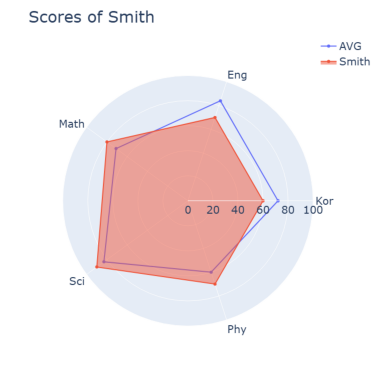

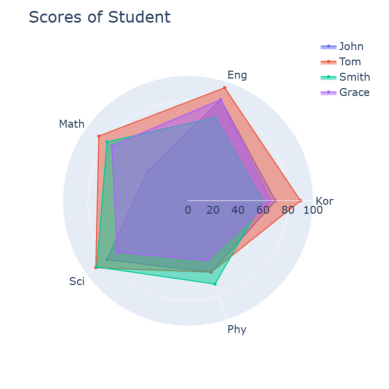

In [3]:
# 예제 데이터
df = pd.DataFrame({
    'Kor': [72, 70, 90, 60, 66],
    'Eng': [84, 85, 95, 70, 85],
    'Math': [71, 40, 88, 80, 75],
    'Sci': [83, 80, 91, 90, 70],
    'Phy': [60, 60, 60, 70, 50]
})
df.index = ['AVG', 'John', 'Tom', 'Smith', 'Grace']
df
fills = [None, 'toself']
radar(df=df.iloc[[0, 3], :],
      fills=fills,
      min_max=[0, 100],
      title='Scores of Smith'
      )
fills = ['toself', 'toself', 'toself', 'toself']
radar(df=df.iloc[1:, :],
      fills=fills,
      min_max=[0, 100],
      title='Scores of Student'
      )

# 8. 트리 맵(Tree Map)

In [4]:
import plotly.express as px
import webbrowser
import matplotlib.pyplot as plt
import pandas as pd

In [6]:
df = pd.read_csv('data/GNI2014.csv')
df.head()

,iso3,country,continent,population,GNI
0,BMU,Bermuda,North America,67837,106140
1,NOR,Norway,Europe,4676305,103630
2,QAT,Qatar,Asia,833285,92200
3,CHE,Switzerland,Europe,7604467,88120
4,MAC,"Macao SAR, China",Asia,559846,76270


In [7]:
fig = px.treemap(data_frame=df,
                 path=['continent', 'iso3'],  # 데이터의 계층 구조
                 values='population',  # 타일 면적 기준 컬럼
                 color='GNI',  # 색 온도 기준 컬럼
                 color_continuous_scale='Bluyl'  # 컬러 팔레트
                 )

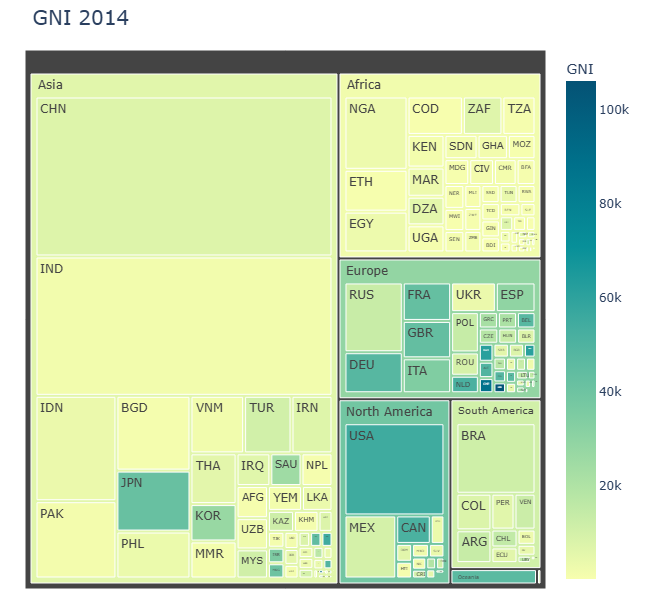

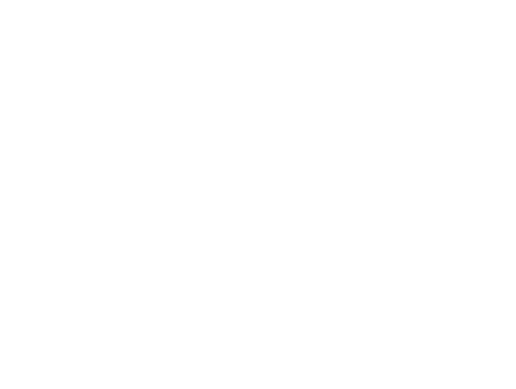

In [8]:
plt.axis('off')  # 축 눈금 제거
fig.update_layout(margin_t=50, margin_l=25,  # 여백 설정
                  margin_r=25, margin_b=25,
                  width=800,  # 그래프의 폭(pixel)
                  height=600,  # 그래프의 높이(pixel)
                  title_text='GNI 2014',  # 그래프 제목
                  title_font_size=20  # 제목 폰트 크기
                  )

In [10]:
# 그래프 저장 & 화면에 표시하기
fig.write_html('d:/treemap.html')  # html 파일로 결과 저장
webbrowser.open('d:/treemap.html')  # 웹 브라우저에서 그래프 확인

FileNotFoundError: [Errno 2] No such file or directory: 'd:\\treemap.html'

In [12]:
fig.write_html('treemap.html')  # 루트 디렉토리 대신 현재 작업 중인 폴더에 저장
webbrowser.open('treemap.html')

True